In [2]:
import cv2
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min

def balanced_k_means(data, k, cluster_size, max_iter=100, num_initializations=10):
    """
    Perform Balanced K-means clustering using scikit-learn.
    
    Args:
        data (ndarray): Data points (n_samples, n_features).
        k (int): Number of clusters.
        cluster_size (int): Desired size of each cluster.
        max_iter (int): Maximum number of iterations for k-means.
        num_initializations (int): Number of initializations to try.
    
    Returns:
        best_labels (ndarray): Cluster labels for each data point.
        best_centroids (ndarray): Final centroids with the lowest inertia.
        best_inertia (float): Minimum inertia achieved.
    """
    n_samples, n_features = data.shape
    assert n_samples == k * cluster_size, "Number of samples must be divisible by cluster size."

    best_inertia = np.inf
    best_labels = None
    best_centroids = None

    for init in range(num_initializations):
        # Use scikit-learn's KMeans to cluster data
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            max_iter=max_iter,
            n_init=1,
            random_state=init
        )
        kmeans.fit(data)

        # Get initial cluster labels and centroids
        initial_labels = kmeans.labels_
        centroids = kmeans.cluster_centers_

        # Enforce balance by reassigning points to clusters
        distances, _ = pairwise_distances_argmin_min(data, centroids)
        sorted_indices = np.argsort(distances)
        clusters = [[] for _ in range(k)]

        for idx in sorted_indices:
            # Assign the point to the least populated cluster
            for cluster_id in range(k):
                if len(clusters[cluster_id]) < cluster_size:
                    clusters[cluster_id].append(idx)
                    break

        # Update labels to reflect balanced assignment
        balanced_labels = np.zeros(n_samples, dtype=int)
        for cluster_id, cluster_indices in enumerate(clusters):
            for idx in cluster_indices:
                balanced_labels[idx] = cluster_id

        # Compute inertia for the balanced clustering
        inertia = sum(
            np.sum((data[clusters[cluster_id]] - centroids[cluster_id])**2)
            for cluster_id in range(k)
        )

        # Update best solution if this is the best inertia so far
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = balanced_labels
            best_centroids = centroids

    return best_labels, best_centroids, best_inertia

In [4]:

# Function to draw a smaller, centered 3x3 grid on an image
def draw_centered_grid(image, grid_size=100):
    h, w, _ = image.shape
    center_x, center_y = w // 2, h // 2

    # Calculate the grid boundaries
    half_size = grid_size // 2
    top_left_x, top_left_y = center_x - half_size, center_y - half_size
    bottom_right_x, bottom_right_y = center_x + half_size, center_y + half_size

    # Draw the grid
    cell_size = grid_size // 3
    for i in range(4):
        y = top_left_y + i * cell_size
        x = top_left_x + i * cell_size
        cv2.line(image, (top_left_x, y), (bottom_right_x, y), (255, 255, 255), 2)
        cv2.line(image, (x, top_left_y), (x, bottom_right_y), (255, 255, 255), 2)

    return image, (top_left_x, top_left_y, cell_size)


# Function to detect the dominant color in a square
def detect_dominant_color(square, neighborhood_fraction=0.25, blur_ksize=5):
    h, w, _ = square.shape
    center_x, center_y = w // 2, h // 2

    # Define the neighborhood size
    offset_x = int(w * neighborhood_fraction // 2)
    offset_y = int(h * neighborhood_fraction // 2)

    # Extract the neighborhood region
    neighborhood = square[center_y - offset_x:center_y + offset_x, center_x - offset_y:center_x + offset_y]

    # Apply Gaussian blur to the neighborhood
    blurred = cv2.GaussianBlur(neighborhood, (blur_ksize, blur_ksize), 0)

    # Calculate the average color in the blurred neighborhood
    avg_color = blurred.mean(axis=0).mean(axis=0)
    return tuple(map(int, avg_color))  # Convert to (B, G, R)


# Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

captured_faces = []  # List to store captured face images
color_data = []  # List to store color data for each face
capture_limit = 6  # Number of faces to capture

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    # Draw the smaller, centered 3x3 grid on the frame
    grid_frame, grid_info = draw_centered_grid(frame.copy(), grid_size=200)

    # Display the live webcam feed with the smaller grid overlay
    cv2.imshow('Align Your Cube and Press Space', grid_frame)

    key = cv2.waitKey(1)

    if key == ord('q') or key == 27:  # Quit on 'q' or 'Esc'
        break
    elif key == ord(' '):  # Capture on spacebar
        if len(captured_faces) < capture_limit:
            captured_faces.append(frame.copy())
            print(f"Captured face {len(captured_faces)}")

            # Analyze grid colors
            top_left_x, top_left_y, cell_size = grid_info
            colors = []
            for i in range(3):
                for j in range(3):
                    x1 = top_left_x + j * cell_size
                    y1 = top_left_y + i * cell_size
                    x2 = x1 + cell_size
                    y2 = y1 + cell_size
                    square = frame[y1:y2, x1:x2]
                    dominant_color = detect_dominant_color(square)
                    colors.append(dominant_color)
            color_data.append(colors)
        else:
            print("All 6 faces have already been captured!")

    # Check if all faces are captured
    if len(captured_faces) == capture_limit:
        break

cap.release()
cv2.destroyAllWindows()

print(color_data)
# Display the final color palette
if len(color_data) == capture_limit:
    # Create a blank canvas for the color palette
    palette_height = 300
    palette_width = 600
    palette = np.zeros((palette_height, palette_width, 3), dtype=np.uint8)

    face_width = palette_width // 6  # Width of each face in the palette
    cell_size = face_width // 3     # Size of each cell within a face

    for face_idx, face_colors in enumerate(color_data):
        for i in range(3):
            for j in range(3):
                color = face_colors[i * 3 + j]
                top_left_x = face_idx * face_width + j * cell_size
                top_left_y = i * cell_size
                bottom_right_x = top_left_x + cell_size
                bottom_right_y = top_left_y + cell_size
                cv2.rectangle(
                    palette,
                    (top_left_x, top_left_y),
                    (bottom_right_x, bottom_right_y),
                    color,  # Convert BGR to RGB for OpenCV
                    -1  # Filled rectangle
                )

    # Show the color palette
    cv2.imshow('Cube Color Palette', palette)

    # Wait for user input to close the window
    print("Press any key in the 'Cube Color Palette' window to close.")
    while True:
        if cv2.waitKey(1) & 0xFF in {ord('q'), 27}:  # Quit on 'q' or 'Esc'
            break

    # Destroy the palette window
    cv2.destroyAllWindows()

2025-01-20 13:42:40.692 Python[25363:24327600] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.
2025-01-20 13:42:42.071 Python[25363:24327600] WARNING: Secure coding is not enabled for restorable state! Enable secure coding by implementing NSApplicationDelegate.applicationSupportsSecureRestorableState: and returning YES.


Captured face 1
Captured face 2
Captured face 3
Captured face 4
Captured face 5
Captured face 6
[[(184, 205, 224), (174, 192, 233), (178, 197, 218), (188, 210, 218), (184, 207, 218), (181, 201, 206), (186, 207, 217), (187, 204, 215), (183, 199, 206)], [(19, 48, 226), (27, 67, 243), (29, 83, 238), (32, 78, 238), (37, 84, 243), (30, 84, 236), (33, 89, 249), (32, 86, 247), (33, 87, 237)], [(58, 206, 105), (55, 205, 99), (56, 201, 102), (54, 202, 100), (56, 206, 99), (58, 199, 101), (56, 202, 102), (54, 201, 92), (56, 199, 102)], [(63, 43, 235), (54, 23, 239), (53, 30, 226), (58, 34, 228), (56, 34, 226), (51, 29, 219), (58, 36, 233), (52, 22, 228), (53, 28, 226)], [(198, 177, 67), (193, 172, 58), (194, 174, 68), (199, 175, 61), (192, 172, 58), (195, 174, 62), (198, 177, 67), (195, 176, 63), (194, 173, 63)], [(36, 225, 231), (32, 227, 218), (32, 225, 221), (32, 220, 235), (27, 226, 229), (32, 221, 227), (35, 222, 228), (33, 222, 215), (36, 224, 222)]]
Press any key in the 'Cube Color Palett

In [5]:
# Example data in BGR format
lab_data_bgr = np.array(color_data)

# Flatten the data to a 2D array of shape (n_samples, 3)
lab_data_bgr_flat = lab_data_bgr.reshape(-1, 3).astype(np.uint8)

# Convert from BGR to LAB using OpenCV
# Reshape the data into a proper image format for color conversion
lab_data_bgr_image = lab_data_bgr_flat.reshape(lab_data_bgr.shape[0], lab_data_bgr.shape[1], 3)  # reshape to (height, width, 3)

lab_data_lab = cv2.cvtColor(lab_data_bgr_image, cv2.COLOR_BGR2LAB)

# Now `lab_data_lab` contains the data in LAB color space
print(lab_data_lab)

k = 6
cluster_size = 9


# Flatten `lab_data` into a 2D array
lab_data_flat = np.array(lab_data_lab).reshape(-1, 3)

# Perform Balanced K-means
labels, centroids, inertia = balanced_k_means(lab_data_flat, k, cluster_size, 100, 1)

# Print results
print("Cluster Labels:", labels)
print("Centroids in LAB:", centroids)
print("Inertia:", inertia)

[[[213 131 141]
  [206 140 143]
  [206 132 140]
  [215 127 140]
  [213 128 141]
  [206 126 139]
  [213 128 140]
  [211 129 138]
  [205 128 137]]

 [[127 194 185]
  [141 193 188]
  [144 185 187]
  [142 187 186]
  [147 187 185]
  [144 184 187]
  [151 187 189]
  [149 187 189]
  [145 184 186]]

 [[190  73 189]
  [189  72 189]
  [186  74 188]
  [186  73 189]
  [189  72 189]
  [184  75 187]
  [187  74 188]
  [185  71 188]
  [184  75 187]]

 [[132 199 166]
  [130 203 170]
  [124 199 168]
  [126 199 166]
  [125 198 166]
  [120 197 167]
  [129 200 167]
  [124 200 169]
  [124 199 168]]

 [[171 104 108]
  [166 103 108]
  [169 104 109]
  [169 104 107]
  [166 103 109]
  [168 104 108]
  [171 104 108]
  [170 103 109]
  [167 104 108]]

 [[223 111 210]
  [222 105 210]
  [221 107 210]
  [221 115 210]
  [223 110 212]
  [220 112 210]
  [221 112 209]
  [218 106 208]
  [221 108 209]]]
Cluster Labels: [3 3 3 3 3 3 3 3 4 1 5 5 5 5 5 5 5 5 4 4 4 4 4 5 4 4 4 0 0 0 0 0 0 0 0 0 1
 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 

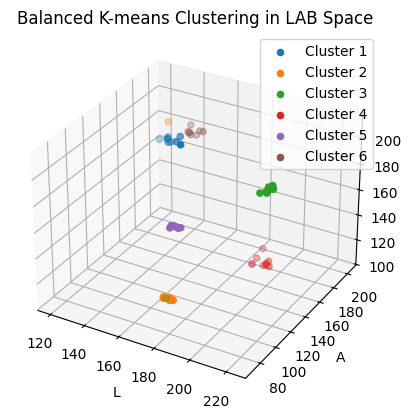

In [11]:
# Convert centroids back to BGR for visualization
bgr_centroids = np.array([cv2.cvtColor(np.uint8([[lab]]), cv2.COLOR_Lab2BGR)[0][0] for lab in centroids])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i in range(k):
    cluster_points = lab_data_flat[labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], label=f"Cluster {i+1}")

ax.set_xlabel('L')
ax.set_ylabel('A')
ax.set_zlabel('B')
ax.legend()
plt.title("Balanced K-means Clustering in LAB Space")
plt.show()

In [7]:
# Flatten lab_data for easier processing with labels
lab_data_flat = np.array(lab_data_lab).reshape(-1, 3)

# Print the indices of items in each cluster
print("Clusters and their indices in the original data list:")

for i in range(k):
    # Find the indices of items belonging to the current cluster
    cluster_indices = np.where(labels == i)[0]  # Indices in the flattened array
    print(f"\nCluster {i+1} (Total points: {len(cluster_indices)}):")
    print(cluster_indices)


Clusters and their indices in the original data list:

Cluster 1 (Total points: 9):
[27 28 29 30 31 32 33 34 35]

Cluster 2 (Total points: 9):
[ 9 36 37 38 39 40 41 42 43]

Cluster 3 (Total points: 9):
[44 45 46 47 48 49 50 51 52]

Cluster 4 (Total points: 9):
[ 0  1  2  3  4  5  6  7 53]

Cluster 5 (Total points: 9):
[ 8 18 19 20 21 22 24 25 26]

Cluster 6 (Total points: 9):
[10 11 12 13 14 15 16 17 23]


In [8]:
# Define cluster-to-color mapping
centre_indices = [4, 22, 13, 31, 40, 49]
picture_order = [0, 2, 1, 3, 4, 5]
color_order = ['W', 'G', 'O', 'R', 'B', 'Y']
cluster_to_color = {}
for i in range(6):
    cluster_to_color[labels[centre_indices[i]]] = color_order[i]

# Example: Assuming `labels` contains the cluster labels for all 54 facelets
# Convert cluster labels to their respective colors

print(cluster_to_color)

print(labels)
facelet_colors = [cluster_to_color[label] for label in labels]

# Reshape to a 6x9 array (6 faces, each with 9 facelets)
facelet_array = np.array(facelet_colors).reshape(6, 9)

new_facelet_array = [facelet_array[picture_order[i]] for i in range(6)]
facelet_array = np.array(new_facelet_array)

# Concatenate the facelets into a single string (row-wise for each face)
facelet_string = ''.join(facelet_array.flatten())

# Print the single-string representation
print("Facelet String Representation:")
print(facelet_string)

{np.int64(3): 'W', np.int64(4): 'G', np.int64(5): 'O', np.int64(0): 'R', np.int64(1): 'B', np.int64(2): 'Y'}
[3 3 3 3 3 3 3 3 4 1 5 5 5 5 5 5 5 5 4 4 4 4 4 5 4 4 4 0 0 0 0 0 0 0 0 0 1
 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 3]
Facelet String Representation:
WWWWWWWWGGGGGGOGGGBOOOOOOOORRRRRRRRRBBBBBBBBYYYYYYYYYW


In [9]:
import main
import cube 
from data import *
import solver

cube = cube.FaceletCube(facelet_string)
cube.rotate_colours_on_face(Move.U3)
cube.rotate_colours_on_face(Move.F2)
cube.rotate_colours_on_face(Move.B2)
cube.rotate_colours_on_face(Move.L2)
cube.rotate_colours_on_face(Move.R2)



print(str(cube))
solver = solver.Solver()
solver.solve_cube(cube)
main.main(str(cube))



pygame 2.6.0 (SDL 2.28.4, Python 3.12.5)
Hello from the pygame community. https://www.pygame.org/contribute.html
WWGWWWWWWGGGOGGGGGOOOOOOOOBRRRRRRRRRYBBBBBBBBYYYYYYYYW


ValueError: ['Y', 'G', 'R'] is not in list

In [ ]:
import numpy as np

# Assuming lab_data_flat is defined elsewhere in your code
data = lab_data_flat

# Initialize adjacency matrix
adjacency_matrix = np.zeros((54, 54), dtype=float)

# Calculate distances and fill the adjacency matrix
for x in range(54):
    for y in range(x, 54):  # Only need to calculate for y > x (since adjacency is symmetric)
        a = data[x]
        b = data[y]
        distance = np.linalg.norm(a - b) 
        adjacency_matrix[x, y] = distance
        adjacency_matrix[y, x] = distance

lowest_weight = (0, np.inf)
for i in range(54):
    row = np.copy(adjacency_matrix[i])
    row_zipped = sorted(enumerate(row), key=lambda x: x[1])[:9]
    total_weight = sum(i[1] for i in row_zipped)
    if total_weight < lowest_weight[1]:
        lowest_weight = (i, total_weight)
        
print(lowest_weight)

row = np.copy(adjacency_matrix[lowest_weight[0]])
row_zipped = sorted(enumerate(row), key=lambda x: x[1])[:9]
print([i[0] for i in row_zipped])

NameError: name 'lab_data_flat' is not defined

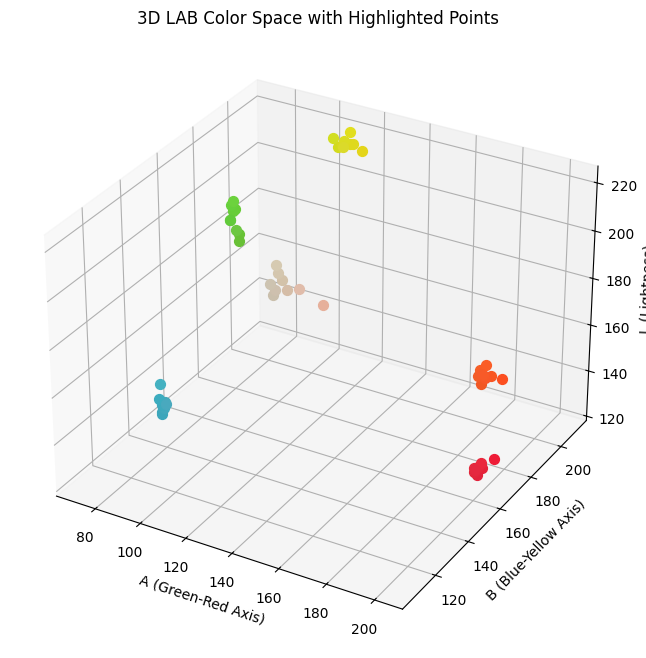

: 

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming lab_data_bgr is in BGR format (values in range [0, 255])
data_bgr = np.array(lab_data_bgr, dtype=np.uint8)  # Ensure proper type

# Convert BGR to LAB using OpenCV
data_lab = cv2.cvtColor(data_bgr.reshape(1, -1, 3), cv2.COLOR_BGR2LAB).reshape(-1, 3)

# Extract LAB components
L = data_lab[:, 0]  # L values (lightness)
A = data_lab[:, 1]  # A values (green-red axis)
B = data_lab[:, 2]  # B values (blue-yellow axis)

# Convert LAB back to RGB for visualization
rgb_array = cv2.cvtColor(data_lab.reshape(1, -1, 3), cv2.COLOR_LAB2RGB).reshape(-1, 3)
rgb_colors = rgb_array / 255.0  # Normalize to [0, 1] for plotting

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of all points in LAB space with original colors
for i in range(len(L)):
    ax.scatter(A[i], B[i], L[i], color=rgb_colors[i], s=50)

# Highlight specific points
highlights = []  # Specify indices of points to highlight
for h in highlights:
    ax.scatter(
        A[h], B[h], L[h], color='red', s=100, edgecolors='black', label="Highlighted Point"
    )

# Add labels and title
ax.set_xlabel('A (Green-Red Axis)')
ax.set_ylabel('B (Blue-Yellow Axis)')
ax.set_zlabel('L (Lightness)')
ax.set_title('3D LAB Color Space with Highlighted Points')

# Show the plot
plt.show()